# Deep Neural Network 직접 구현

NumPy를 사용한 Dense DNN의 Forward / Backward Propagation, Mini-batch SGD 및 Gradient checking.


## 1. 데이터·레이어·모델 구현
입력 배열은 `(batch, features)`, label은 `(batch,)` 정수로 유지한다.

In [1]:
import numpy as np

def load_data(n_samples=1000, seed=42):
    rng = np.random.default_rng(seed)
    y = np.arange(n_samples) % 2
    t = rng.uniform(0, 2 * np.pi, n_samples)
    r = np.where(y == 0, 1.0, 0.4)
    X = np.column_stack([r * np.cos(t), r * np.sin(t)]) + rng.normal(0, 0.06, (n_samples, 2))
    idx = rng.permutation(n_samples)
    cut = int(0.8 * n_samples)
    a, b = (idx[:cut], idx[cut:])
    mean, std = (X[a].mean(0), np.maximum(X[a].std(0), 1e-12))
    return ((X[a] - mean) / std, y[a], (X[b] - mean) / std, y[b])

def get_batches(X, y, batch_size, shuffle=True, rng=None):
    if X.ndim != 2 or y.shape != (len(X),) or (not len(X)):
        raise ValueError('X:(N,D), y:(N,)')
    if not isinstance(batch_size, (int, np.integer)) or batch_size <= 0:
        raise ValueError('positive integer batch size')
    rng = np.random.default_rng() if rng is None else rng
    idx = rng.permutation(len(X)) if shuffle else np.arange(len(X))
    for start in range(0, len(X), batch_size):
        i = idx[start:start + batch_size]
        yield (X[i], y[i])

class DenseLayer:

    def __init__(self, in_features, out_features, rng, initialization='he'):
        if initialization not in ('he', 'xavier'):
            raise ValueError('he or xavier')
        self.W = rng.normal(size=(in_features, out_features)) * np.sqrt((2 if initialization == 'he' else 1) / in_features)
        self.b = np.zeros((1, out_features))
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)

    def forward(self, X):
        if X.ndim != 2 or X.shape[1] != self.W.shape[0]:
            raise ValueError('input shape')
        self.X = X.copy()
        return X @ self.W + self.b

    def backward(self, dout):
        if dout.shape != (len(self.X), self.W.shape[1]):
            raise ValueError('gradient shape')
        self.dW = self.X.T @ dout
        self.db = dout.sum(0, keepdims=True)
        return dout @ self.W.T

class ReLU:

    def forward(self, X):
        self.mask = X > 0
        return np.maximum(X, 0)

    def backward(self, dout):
        if dout.shape != self.mask.shape:
            raise ValueError('gradient shape')
        return dout * self.mask

class Tanh:

    def forward(self, X):
        self.out = np.tanh(X)
        return self.out.copy()

    def backward(self, dout):
        if dout.shape != self.out.shape:
            raise ValueError('gradient shape')
        return dout * (1 - self.out ** 2)

class SoftmaxCrossEntropy:

    def forward(self, logits, y):
        if logits.ndim != 2 or not len(logits) or y.shape != (len(logits),):
            raise ValueError('logits:(N,C), y:(N,)')
        if not np.issubdtype(y.dtype, np.integer) or np.any(y < 0) or np.any(y >= logits.shape[1]):
            raise ValueError('class indices')
        z = logits - logits.max(1, keepdims=True)
        logp = z - np.log(np.exp(z).sum(1, keepdims=True))
        self.probs = np.exp(logp)
        self.y = y.copy()
        return float(-logp[np.arange(len(y)), y].mean())

    def backward(self):
        grad = self.probs.copy()
        grad[np.arange(len(self.y)), self.y] -= 1
        return grad / len(self.y)

class DeepNeuralNetwork:

    def __init__(self, layers):
        self.layers = layers

    def forward(self, X):
        for layer in self.layers:
            X = layer.forward(X)
        return X

    def backward(self, dout):
        for layer in reversed(self.layers):
            dout = layer.backward(dout)
        return dout

    def step(self, learning_rate):
        if learning_rate <= 0:
            raise ValueError('positive learning rate')
        for layer in self.layers:
            if isinstance(layer, DenseLayer):
                layer.W -= learning_rate * layer.dW
                layer.b -= learning_rate * layer.db

def build_model(seed=7):
    rng = np.random.default_rng(seed)
    return DeepNeuralNetwork([DenseLayer(2, 16, rng), ReLU(), DenseLayer(16, 8, rng, 'xavier'), Tanh(), DenseLayer(8, 2, rng, 'xavier')])

def gradient_check(model, X, y, epsilon=1e-05):
    loss = SoftmaxCrossEntropy()
    loss.forward(model.forward(X), y)
    model.backward(loss.backward())
    saved = [(i, n, getattr(l, 'd' + n).copy()) for i, l in enumerate(model.layers) if isinstance(l, DenseLayer) for n in ('W', 'b')]
    errors = {}
    for i, name, analytic in saved:
        p = getattr(model.layers[i], name)
        numeric = np.zeros_like(p)
        for idx in np.ndindex(p.shape):
            old = p[idx]
            try:
                p[idx] = old + epsilon
                plus = loss.forward(model.forward(X), y)
                p[idx] = old - epsilon
                minus = loss.forward(model.forward(X), y)
                numeric[idx] = (plus - minus) / (2 * epsilon)
            finally:
                p[idx] = old
        errors[f'layer_{i}.{name}'] = float(np.linalg.norm(analytic - numeric) / (np.linalg.norm(analytic) + np.linalg.norm(numeric) + 1e-12))
    loss.forward(model.forward(X), y)
    model.backward(loss.backward())
    return errors

def evaluate(model, X, y):
    logits = model.forward(X)
    return (SoftmaxCrossEntropy().forward(logits, y), float(np.mean(logits.argmax(1) == y)))

def train(epochs=200, batch_size=32, learning_rate=0.05, seed=42):
    X, y, Xv, yv = load_data(seed=seed)
    model = build_model()
    loss = SoftmaxCrossEntropy()
    rng = np.random.default_rng(seed + 1)
    history = []
    for epoch in range(1, epochs + 1):
        for xb, yb in get_batches(X, y, batch_size, rng=rng):
            loss.forward(model.forward(xb), yb)
            model.backward(loss.backward())
            model.step(learning_rate)
        tl, ta = evaluate(model, X, y)
        vl, va = evaluate(model, Xv, yv)
        history.append(dict(epoch=epoch, train_loss=tl, train_accuracy=ta, val_loss=vl, val_accuracy=va))
    return (model, history)


## 2. 수치미분 검사와 학습률 비교 실험

In [2]:
import csv
import json
from pathlib import Path
import matplotlib.pyplot as plt

results_dir = Path("results")
results_dir.mkdir(exist_ok=True)
X_train, y_train, X_val, y_val = load_data()
print("데이터 shape:", X_train.shape, y_train.shape, X_val.shape, y_val.shape)
errors = gradient_check(build_model(), X_train[:5], y_train[:5])
for name, error in errors.items():
    print(f"Gradient checking {name}: {error:.3e}")
assert max(errors.values()) < 1e-6

histories = {}
summary = {"gradient_check": errors, "experiments": []}
for lr in (0.01, 0.05):
    model, history = train(epochs=200, batch_size=32, learning_rate=lr, seed=42)
    histories[lr] = history
    with (results_dir / f"logs_lr_{lr}.csv").open("w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=list(history[0]))
        writer.writeheader()
        writer.writerows(history)
    summary["experiments"].append({"learning_rate": lr, "final": history[-1]})
    for h in history:
        if h["epoch"] == 1 or h["epoch"] % 50 == 0:
            print(f"lr={lr}, epoch={h['epoch']:3d}, train loss={h['train_loss']:.6f}, "
                  f"train acc={h['train_accuracy']:.1%}, val loss={h['val_loss']:.6f}, "
                  f"val acc={h['val_accuracy']:.1%}")
(results_dir / "summary.json").write_text(json.dumps(summary, indent=2))


데이터 shape: (800, 2) (800,) (200, 2) (200,)
Gradient checking layer_0.W: 5.710e-11
Gradient checking layer_0.b: 3.929e-11
Gradient checking layer_2.W: 6.888e-11
Gradient checking layer_2.b: 5.641e-11
Gradient checking layer_4.W: 2.101e-11
Gradient checking layer_4.b: 2.287e-11
lr=0.01, epoch=  1, train loss=0.695601, train acc=51.0%, val loss=0.705006, val acc=49.0%
lr=0.01, epoch= 50, train loss=0.086838, train acc=100.0%, val loss=0.093583, val acc=100.0%
lr=0.01, epoch=100, train loss=0.026837, train acc=100.0%, val loss=0.031065, val acc=100.0%
lr=0.01, epoch=150, train loss=0.014625, train acc=100.0%, val loss=0.017735, val acc=100.0%
lr=0.01, epoch=200, train loss=0.009770, train acc=100.0%, val loss=0.012252, val acc=100.0%
lr=0.05, epoch=  1, train loss=0.591758, train acc=70.4%, val loss=0.603256, val acc=68.0%
lr=0.05, epoch= 50, train loss=0.007191, train acc=100.0%, val loss=0.009320, val acc=100.0%
lr=0.05, epoch=100, train loss=0.002941, train acc=100.0%, val loss=0.004128

## 3. 학습 곡선

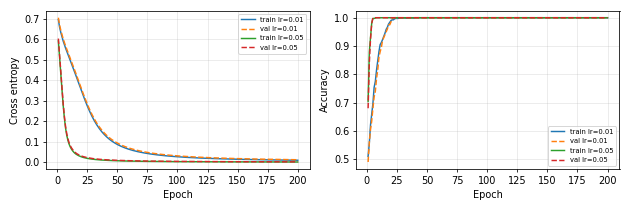

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for lr, history in histories.items():
    epochs = [h["epoch"] for h in history]
    axes[0].plot(epochs, [h["train_loss"] for h in history], label=f"train lr={lr}")
    axes[0].plot(epochs, [h["val_loss"] for h in history], "--", label=f"val lr={lr}")
    axes[1].plot(epochs, [h["train_accuracy"] for h in history], label=f"train lr={lr}")
    axes[1].plot(epochs, [h["val_accuracy"] for h in history], "--", label=f"val lr={lr}")
for ax, title, ylabel in zip(axes, ["Loss", "Accuracy"], ["Cross entropy", "Accuracy"]):
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(results_dir / "learning_curves.png", dpi=120)
plt.show()


# DNN Forward / Backward Propagation 구현 보고서

## 모델과 데이터
NumPy로 2차원 circles 데이터 1,000개를 직접 생성했다. 반지름 1.0과 0.4인 원에 표준편차 0.06의 가우시안 잡음을 더했다.
무작위로 학습 800개 / 검증 200개를 분할했으며 학습 데이터의 평균과 표준편차만 사용해 두 데이터를 표준화했다.
별도 최종 테스트 세트는 없으므로 기록한 성능은 검증 성능이다.

모델: 입력(2) → Dense(16) → ReLU → Dense(8) → Tanh → Dense(2) → Softmax Cross Entropy.
Dense는 총 3개, 은닉층은 2개, 학습 파라미터는 총 202개다.
모든 레이어는 (batch, features)를 유지한다. 가중치는 (입력차원, 출력차원), 편향은 (1, 출력차원)이다.
입력은 (N,2), 은닉층 출력은 (N,16), (N,8), 최종 logits은 (N,2)이다.

## 초기화·활성함수·손실함수
ReLU 앞 Dense는 He 초기화, Tanh와 출력 Dense는 Xavier 초기화를 적용했다. 편향은 0으로 초기화했다.
ReLU는 간단한 비선형성을 제공하며 양수 영역에서 기울기를 유지한다. Tanh는 매끄러운 비선형성을 제공한다.
두 클래스의 logits에 Softmax Cross Entropy를 적용하여 확률 정규화와 분류 손실을 함께 계산했다.
행별 최대 logits를 빼고 log-sum-exp를 사용하여 큰 값에서의 overflow를 방지했다.

## Forward와 직접 미분
Dense는 Z = XW+b를 계산하고 입력 X를 cache에 저장한다.
ReLU는 X>0 마스크를, Tanh는 활성화 출력을, 손실은 확률과 정답 label을 저장한다.

- Dense: dW = XᵀdZ, db = sum(dZ, axis=0, keepdims=True), dX = dZWᵀ.
- ReLU: dX = dout × 1[X>0]. X=0에서 미분값은 0으로 정의한다.
- Tanh: dX = dout × (1−tanh(X)²).
- Softmax CE: dlogits = (softmax(logits)−one_hot(y))/N.

배치 평균은 손실의 backward에서 한 번만 적용한다. Dense에서 다시 배치 크기로 나누지 않는다.
모델의 backward는 레이어를 역순으로 방문하며, SGD는 W←W−lr×dW, b←b−lr×db로 갱신한다.
자동미분 또는 딥러닝 프레임워크를 사용하지 않았다.

## Gradient checking
모델 seed=7, 데이터 seed=42의 학습 샘플 5개에 대해 모든 Dense의 W와 b를 검사했다.
중앙차분 g_num = (L(θ+ε)−L(θ−ε))/(2ε), ε=1e-5를 사용했다.
상대오차 = ||g_analytic−g_num||₂/(||g_analytic||₂+||g_num||₂+1e-12).
통과 기준은 1e-6이며 수치미분 후 원래 파라미터와 cache를 복원한다.

| 파라미터 | 상대오차 |
|---|---|
| layer_0.W | 5.710e-11 |
| layer_0.b | 3.929e-11 |
| layer_2.W | 6.888e-11 |
| layer_2.b | 5.641e-11 |
| layer_4.W | 2.101e-11 |
| layer_4.b | 2.287e-11 |

ReLU는 0에서 미분이 불연속이므로 수치미분에 사용한 입력에서 꺾이는 지점을 피해야 한다.
위 검사에서는 모든 오차가 기준보다 작아 통과했다.

## 실험 결과
200 epoch, batch size=32, 데이터 seed=42, 모델 seed=7, SGD를 사용했다.
같은 데이터·초기화·배치 순서에서 학습률만 0.01과 0.05로 바꾸었다.
매 epoch가 끝난 뒤 같은 파라미터 상태로 전체 학습/검증 loss와 accuracy를 계산했다.

| 학습률 | Train loss | Train accuracy | Val loss | Val accuracy |
|---|---|---|---|---|
| 0.01 | 0.009770 | 100.0% | 0.012252 | 100.0% |
| 0.05 | 0.001253 | 100.0% | 0.001908 | 100.0% |

두 학습률 모두 검증 정확도 100%에 도달했으며 0.05가 더 낮은 최종 loss를 기록했다.
각 epoch 로그는 CSV로 저장하며 아래 코드에서 loss/accuracy 곡선을 출력한다.
한 종류의 쉬운 toy 데이터와 단일 seed로 실험했으므로 일반 데이터의 성능으로 해석하지 않는다.

## 실행 방법
Google Colab에서 이 ipynb 파일을 열고 런타임 → 모두 실행을 선택한다. GPU 또는 외부 데이터 파일이 필요 없다.
실행하면 src/dnn.py, README.md, results/summary.json, epoch별 CSV 및 학습 곡선 PNG가 생성된다.
첨부 Optimization.ipynb의 mini-batch/SGD 학습 흐름을 참고하되 (batch, features) 조건과 레이어 API에 맞추어 재구성했다.
data.mat 대신 NumPy로 데이터를 직접 생성했다.


## 4. 소스와 README 저장

In [4]:
from pathlib import Path
Path('src').mkdir(exist_ok=True)
Path('src/dnn.py').write_text("import numpy as np\n\ndef load_data(n_samples=1000, seed=42):\n    rng = np.random.default_rng(seed)\n    y = np.arange(n_samples) % 2\n    t = rng.uniform(0, 2 * np.pi, n_samples)\n    r = np.where(y == 0, 1.0, 0.4)\n    X = np.column_stack([r * np.cos(t), r * np.sin(t)]) + rng.normal(0, 0.06, (n_samples, 2))\n    idx = rng.permutation(n_samples)\n    cut = int(0.8 * n_samples)\n    a, b = (idx[:cut], idx[cut:])\n    mean, std = (X[a].mean(0), np.maximum(X[a].std(0), 1e-12))\n    return ((X[a] - mean) / std, y[a], (X[b] - mean) / std, y[b])\n\ndef get_batches(X, y, batch_size, shuffle=True, rng=None):\n    if X.ndim != 2 or y.shape != (len(X),) or (not len(X)):\n        raise ValueError('X:(N,D), y:(N,)')\n    if not isinstance(batch_size, (int, np.integer)) or batch_size <= 0:\n        raise ValueError('positive integer batch size')\n    rng = np.random.default_rng() if rng is None else rng\n    idx = rng.permutation(len(X)) if shuffle else np.arange(len(X))\n    for start in range(0, len(X), batch_size):\n        i = idx[start:start + batch_size]\n        yield (X[i], y[i])\n\nclass DenseLayer:\n\n    def __init__(self, in_features, out_features, rng, initialization='he'):\n        if initialization not in ('he', 'xavier'):\n            raise ValueError('he or xavier')\n        self.W = rng.normal(size=(in_features, out_features)) * np.sqrt((2 if initialization == 'he' else 1) / in_features)\n        self.b = np.zeros((1, out_features))\n        self.dW = np.zeros_like(self.W)\n        self.db = np.zeros_like(self.b)\n\n    def forward(self, X):\n        if X.ndim != 2 or X.shape[1] != self.W.shape[0]:\n            raise ValueError('input shape')\n        self.X = X.copy()\n        return X @ self.W + self.b\n\n    def backward(self, dout):\n        if dout.shape != (len(self.X), self.W.shape[1]):\n            raise ValueError('gradient shape')\n        self.dW = self.X.T @ dout\n        self.db = dout.sum(0, keepdims=True)\n        return dout @ self.W.T\n\nclass ReLU:\n\n    def forward(self, X):\n        self.mask = X > 0\n        return np.maximum(X, 0)\n\n    def backward(self, dout):\n        if dout.shape != self.mask.shape:\n            raise ValueError('gradient shape')\n        return dout * self.mask\n\nclass Tanh:\n\n    def forward(self, X):\n        self.out = np.tanh(X)\n        return self.out.copy()\n\n    def backward(self, dout):\n        if dout.shape != self.out.shape:\n            raise ValueError('gradient shape')\n        return dout * (1 - self.out ** 2)\n\nclass SoftmaxCrossEntropy:\n\n    def forward(self, logits, y):\n        if logits.ndim != 2 or not len(logits) or y.shape != (len(logits),):\n            raise ValueError('logits:(N,C), y:(N,)')\n        if not np.issubdtype(y.dtype, np.integer) or np.any(y < 0) or np.any(y >= logits.shape[1]):\n            raise ValueError('class indices')\n        z = logits - logits.max(1, keepdims=True)\n        logp = z - np.log(np.exp(z).sum(1, keepdims=True))\n        self.probs = np.exp(logp)\n        self.y = y.copy()\n        return float(-logp[np.arange(len(y)), y].mean())\n\n    def backward(self):\n        grad = self.probs.copy()\n        grad[np.arange(len(self.y)), self.y] -= 1\n        return grad / len(self.y)\n\nclass DeepNeuralNetwork:\n\n    def __init__(self, layers):\n        self.layers = layers\n\n    def forward(self, X):\n        for layer in self.layers:\n            X = layer.forward(X)\n        return X\n\n    def backward(self, dout):\n        for layer in reversed(self.layers):\n            dout = layer.backward(dout)\n        return dout\n\n    def step(self, learning_rate):\n        if learning_rate <= 0:\n            raise ValueError('positive learning rate')\n        for layer in self.layers:\n            if isinstance(layer, DenseLayer):\n                layer.W -= learning_rate * layer.dW\n                layer.b -= learning_rate * layer.db\n\ndef build_model(seed=7):\n    rng = np.random.default_rng(seed)\n    return DeepNeuralNetwork([DenseLayer(2, 16, rng), ReLU(), DenseLayer(16, 8, rng, 'xavier'), Tanh(), DenseLayer(8, 2, rng, 'xavier')])\n\ndef gradient_check(model, X, y, epsilon=1e-05):\n    loss = SoftmaxCrossEntropy()\n    loss.forward(model.forward(X), y)\n    model.backward(loss.backward())\n    saved = [(i, n, getattr(l, 'd' + n).copy()) for i, l in enumerate(model.layers) if isinstance(l, DenseLayer) for n in ('W', 'b')]\n    errors = {}\n    for i, name, analytic in saved:\n        p = getattr(model.layers[i], name)\n        numeric = np.zeros_like(p)\n        for idx in np.ndindex(p.shape):\n            old = p[idx]\n            try:\n                p[idx] = old + epsilon\n                plus = loss.forward(model.forward(X), y)\n                p[idx] = old - epsilon\n                minus = loss.forward(model.forward(X), y)\n                numeric[idx] = (plus - minus) / (2 * epsilon)\n            finally:\n                p[idx] = old\n        errors[f'layer_{i}.{name}'] = float(np.linalg.norm(analytic - numeric) / (np.linalg.norm(analytic) + np.linalg.norm(numeric) + 1e-12))\n    loss.forward(model.forward(X), y)\n    model.backward(loss.backward())\n    return errors\n\ndef evaluate(model, X, y):\n    logits = model.forward(X)\n    return (SoftmaxCrossEntropy().forward(logits, y), float(np.mean(logits.argmax(1) == y)))\n\ndef train(epochs=200, batch_size=32, learning_rate=0.05, seed=42):\n    X, y, Xv, yv = load_data(seed=seed)\n    model = build_model()\n    loss = SoftmaxCrossEntropy()\n    rng = np.random.default_rng(seed + 1)\n    history = []\n    for epoch in range(1, epochs + 1):\n        for xb, yb in get_batches(X, y, batch_size, rng=rng):\n            loss.forward(model.forward(xb), yb)\n            model.backward(loss.backward())\n            model.step(learning_rate)\n        tl, ta = evaluate(model, X, y)\n        vl, va = evaluate(model, Xv, yv)\n        history.append(dict(epoch=epoch, train_loss=tl, train_accuracy=ta, val_loss=vl, val_accuracy=va))\n    return (model, history)\n", encoding='utf-8')
Path('README.md').write_text('# DNN Forward / Backward Propagation 구현 보고서\n\n## 모델과 데이터\nNumPy로 2차원 circles 데이터 1,000개를 직접 생성했다. 반지름 1.0과 0.4인 원에 표준편차 0.06의 가우시안 잡음을 더했다.\n무작위로 학습 800개 / 검증 200개를 분할했으며 학습 데이터의 평균과 표준편차만 사용해 두 데이터를 표준화했다.\n별도 최종 테스트 세트는 없으므로 기록한 성능은 검증 성능이다.\n\n모델: 입력(2) → Dense(16) → ReLU → Dense(8) → Tanh → Dense(2) → Softmax Cross Entropy.\nDense는 총 3개, 은닉층은 2개, 학습 파라미터는 총 202개다.\n모든 레이어는 (batch, features)를 유지한다. 가중치는 (입력차원, 출력차원), 편향은 (1, 출력차원)이다.\n입력은 (N,2), 은닉층 출력은 (N,16), (N,8), 최종 logits은 (N,2)이다.\n\n## 초기화·활성함수·손실함수\nReLU 앞 Dense는 He 초기화, Tanh와 출력 Dense는 Xavier 초기화를 적용했다. 편향은 0으로 초기화했다.\nReLU는 간단한 비선형성을 제공하며 양수 영역에서 기울기를 유지한다. Tanh는 매끄러운 비선형성을 제공한다.\n두 클래스의 logits에 Softmax Cross Entropy를 적용하여 확률 정규화와 분류 손실을 함께 계산했다.\n행별 최대 logits를 빼고 log-sum-exp를 사용하여 큰 값에서의 overflow를 방지했다.\n\n## Forward와 직접 미분\nDense는 Z = XW+b를 계산하고 입력 X를 cache에 저장한다.\nReLU는 X>0 마스크를, Tanh는 활성화 출력을, 손실은 확률과 정답 label을 저장한다.\n\n- Dense: dW = XᵀdZ, db = sum(dZ, axis=0, keepdims=True), dX = dZWᵀ.\n- ReLU: dX = dout × 1[X>0]. X=0에서 미분값은 0으로 정의한다.\n- Tanh: dX = dout × (1−tanh(X)²).\n- Softmax CE: dlogits = (softmax(logits)−one_hot(y))/N.\n\n배치 평균은 손실의 backward에서 한 번만 적용한다. Dense에서 다시 배치 크기로 나누지 않는다.\n모델의 backward는 레이어를 역순으로 방문하며, SGD는 W←W−lr×dW, b←b−lr×db로 갱신한다.\n자동미분 또는 딥러닝 프레임워크를 사용하지 않았다.\n\n## Gradient checking\n모델 seed=7, 데이터 seed=42의 학습 샘플 5개에 대해 모든 Dense의 W와 b를 검사했다.\n중앙차분 g_num = (L(θ+ε)−L(θ−ε))/(2ε), ε=1e-5를 사용했다.\n상대오차 = ||g_analytic−g_num||₂/(||g_analytic||₂+||g_num||₂+1e-12).\n통과 기준은 1e-6이며 수치미분 후 원래 파라미터와 cache를 복원한다.\n\n| 파라미터 | 상대오차 |\n|---|---|\n| layer_0.W | 5.710e-11 |\n| layer_0.b | 3.929e-11 |\n| layer_2.W | 6.888e-11 |\n| layer_2.b | 5.641e-11 |\n| layer_4.W | 2.101e-11 |\n| layer_4.b | 2.287e-11 |\n\nReLU는 0에서 미분이 불연속이므로 수치미분에 사용한 입력에서 꺾이는 지점을 피해야 한다.\n위 검사에서는 모든 오차가 기준보다 작아 통과했다.\n\n## 실험 결과\n200 epoch, batch size=32, 데이터 seed=42, 모델 seed=7, SGD를 사용했다.\n같은 데이터·초기화·배치 순서에서 학습률만 0.01과 0.05로 바꾸었다.\n매 epoch가 끝난 뒤 같은 파라미터 상태로 전체 학습/검증 loss와 accuracy를 계산했다.\n\n| 학습률 | Train loss | Train accuracy | Val loss | Val accuracy |\n|---|---|---|---|---|\n| 0.01 | 0.009770 | 100.0% | 0.012252 | 100.0% |\n| 0.05 | 0.001253 | 100.0% | 0.001908 | 100.0% |\n\n두 학습률 모두 검증 정확도 100%에 도달했으며 0.05가 더 낮은 최종 loss를 기록했다.\n각 epoch 로그는 CSV로 저장하며 아래 코드에서 loss/accuracy 곡선을 출력한다.\n한 종류의 쉬운 toy 데이터와 단일 seed로 실험했으므로 일반 데이터의 성능으로 해석하지 않는다.\n\n## 실행 방법\nGoogle Colab에서 이 ipynb 파일을 열고 런타임 → 모두 실행을 선택한다. GPU 또는 외부 데이터 파일이 필요 없다.\n실행하면 src/dnn.py, README.md, results/summary.json, epoch별 CSV 및 학습 곡선 PNG가 생성된다.\n첨부 Optimization.ipynb의 mini-batch/SGD 학습 흐름을 참고하되 (batch, features) 조건과 레이어 API에 맞추어 재구성했다.\ndata.mat 대신 NumPy로 데이터를 직접 생성했다.\n', encoding='utf-8')
print('저장 완료: src/dnn.py, README.md, results/')


저장 완료: src/dnn.py, README.md, results/
